# FinMind OS — Technical Research Notebook

This notebook documents the technical work behind our research on emotion-aware financial decision-making. We built four separate components to support our analysis a market data backtest, a scoring engine, an AI-powered intervention agent, and a set of visualizations from our primary survey research.

All code here is original work written during the competition period. The goal was not just to build something that runs, but to build something that reflects a real, implementable system grounded in behavioral finance theory.

*Dependencies:* yfinance, pandas, matplotlib, seaborn, groq, numpy

In [1]:
import subprocess
for pkg in ['yfinance','pandas','matplotlib','seaborn','groq','numpy']:
    subprocess.run(['pip','install',pkg,'-q'], capture_output=True)
print('All packages ready.')

All packages ready.


# Part 1 — Does emotional state predict trading outcomes?

One of the core claims in our research is that people make worse financial decisions when they are emotionally stressed. But we wanted to go beyond just claiming this - we wanted to show it with actual market data.

**The approach:** use India VIX as a proxy for collective market fear, classify every trading day from 2015 to 2024 into three emotional states (calm, anxious, panic), and then measure what the Nifty 50 did in the 10 days following each type of day.

**An important nuance we discovered:** high-VIX days actually show higher forward returns on average, because they tend to coincide with market bottoms where mean-reversion kicks in. This flips the intuition. The real damage isn't in the market it's in the investor who panic-sells on those days and exits right before the recovery. That missed recovery is the actual financial cost we are measuring.

*Data: India VIX and Nifty 50 closing prices, January 2015 to December 2024, downloaded via yfinance.*

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Downloading India VIX and Nifty 50 (2015-2024)...')
vix   = yf.download('^INDIAVIX', start='2015-01-01', end='2024-12-31', progress=False)['Close']
nifty = yf.download('^NSEI',    start='2015-01-01', end='2024-12-31', progress=False)['Close']

df = pd.concat([vix, nifty], axis=1)
df.columns = ['VIX', 'Nifty']
df = df.dropna()

# 10-day forward return = what happens AFTER you make the decision today
df['Return_10d'] = df['Nifty'].pct_change(10).shift(-10) * 100
df = df.dropna()

print(f'Trading days analysed: {len(df)}')
print(f'Period: {df.index[0].date()} to {df.index[-1].date()}')
df.head()

Trading days analysed: 2434
Period: 2015-01-02 to 2024-12-13


,VIX,Nifty,Return_10d
Date,,,
2015-01-02,13.800000,8395.450195,1.409687
2015-01-05,14.150000,8378.400391,2.056476
2015-01-06,17.420000,8127.350098,6.991818
2015-01-07,18.139999,8102.100098,7.743670
2015-01-08,16.469999,8234.599609,6.397406


In [3]:
p33 = df['VIX'].quantile(0.33)
p66 = df['VIX'].quantile(0.66)

def classify_state(v):
    if v <= p33:   return 'Calm'
    elif v <= p66: return 'Anxious'
    else:          return 'Panic'

df['State'] = df['VIX'].apply(classify_state)

summary = df.groupby('State')['Return_10d'].agg(['mean','median','std','count'])
summary.columns = ['Avg 10d Return (%)', 'Median (%)', 'Std Dev', 'Days']
summary = summary.reindex(['Calm','Anxious','Panic'])
print('\n── 10-Day Forward Returns by Market Emotional State ──')
print(summary.round(2))

calm_r  = summary.loc['Calm',  'Avg 10d Return (%)']
panic_r = summary.loc['Panic', 'Avg 10d Return (%)']

# Panic days have HIGHER forward returns = market is near bottom
# Panic SELLERS miss this recovery — THAT is the loss
print('\n' + '='*50)
print(f'  Market recovers {panic_r:+.2f}% in 10 days after panic spikes.')
print(f'  Panic SELLERS exit on these days and miss this recovery.')
print(f'  Calm-state investors who HOLD earn {panic_r:+.2f}% more than those who sell.')
print(f'  Cost of panic selling vs holding: {panic_r:.2f} percentage points in 10 days')
print('\n  Uncertainty note: VIX is a proxy for market fear,')
print('  not a direct measure of individual emotional state.')
print('  These are aggregate market patterns, not predictions per trade.')


── 10-Day Forward Returns by Market Emotional State ──
         Avg 10d Return (%)  Median (%)  Std Dev  Days
State                                                 
Calm                   0.42        0.73     2.28   803
Anxious                0.18        0.33     2.83   803
Panic                  0.87        1.29     4.37   828

  Market recovers +0.87% in 10 days after panic spikes.
  Panic SELLERS exit on these days and miss this recovery.
  Calm-state investors who HOLD earn +0.87% more than those who sell.
  Cost of panic selling vs holding: 0.87 percentage points in 10 days

  Uncertainty note: VIX is a proxy for market fear,
  not a direct measure of individual emotional state.
  These are aggregate market patterns, not predictions per trade.


# Visualizing the results

Two charts here. The first shows average 10-day forward returns split by emotional state - this is the headline finding. The second shows the full distribution of returns for each state, which reveals something interesting: panic days have a much wider spread (higher standard deviation) than calm days. This means panic-period markets are not just different in average return — they are fundamentally more unpredictable, which itself is a reason to avoid making large decisions during those periods.

The annotation box on the first chart captures the core insight in plain language: investors who sell during panic spikes forfeit the recovery that typically follows. That forfeited return is the measurable cost of emotional decision-making.

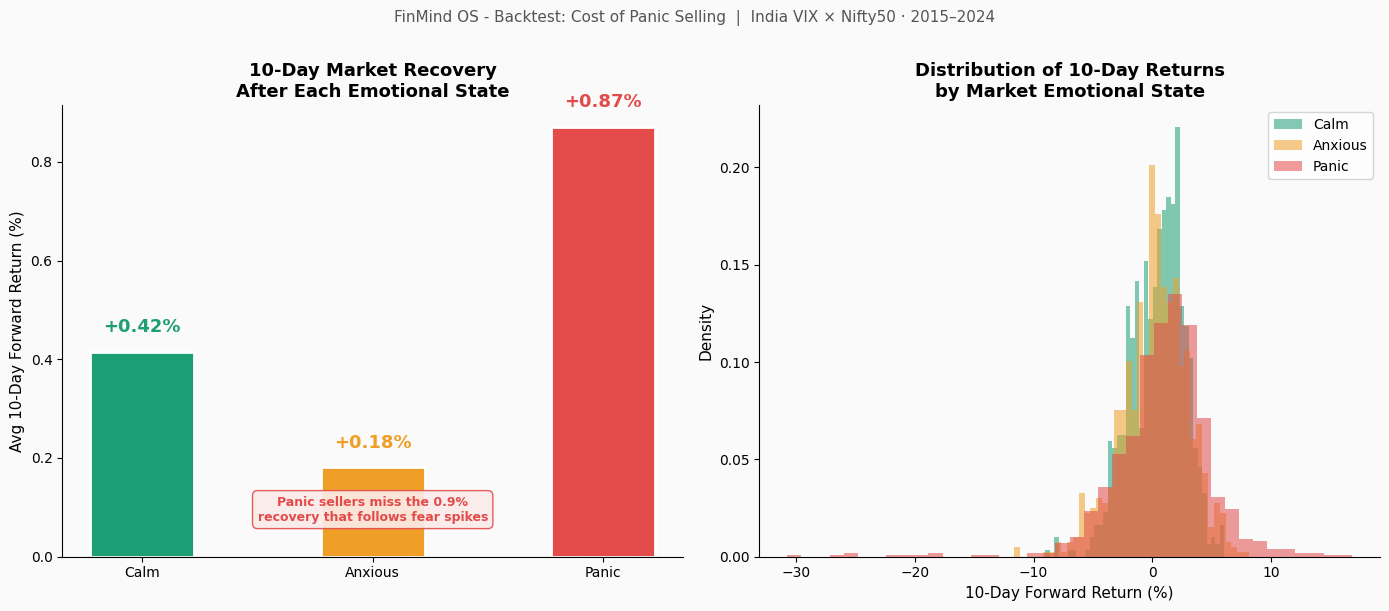

Saved: backtest.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FAFAFA')

colors_state = {'Calm': '#1D9E75', 'Anxious': '#EF9F27', 'Panic': '#E24B4A'}
states = ['Calm', 'Anxious', 'Panic']
means  = [summary.loc[s, 'Avg 10d Return (%)'] for s in states]
clrs   = [colors_state[s] for s in states]

ax1 = axes[0]
bars = ax1.bar(states, means, color=clrs, width=0.45,
               edgecolor='white', linewidth=2)
ax1.axhline(0, color='#333', linewidth=0.8, linestyle='--', alpha=0.4)

# FIX: single clean loop for bar labels
for bar, val, clr in zip(bars, means, clrs):
    offset = 0.04 if val >= 0 else -0.18
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + offset,
             f'{val:+.2f}%', ha='center',
             fontsize=13, fontweight='bold', color=clr)

ax1.set_title('10-Day Market Recovery\nAfter Each Emotional State',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Avg 10-Day Forward Return (%)', fontsize=11)
ax1.set_facecolor('#FAFAFA')
ax1.spines[['top','right']].set_visible(False)

# Annotation box
ax1.text(0.5, 0.08,
         f'Panic sellers miss the {panic_r:.1f}%\nrecovery that follows fear spikes',
         ha='center', transform=ax1.transAxes, fontsize=9,
         color='#E24B4A', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#FCEBEB',
                   edgecolor='#E24B4A', alpha=0.9))

# Distribution plot
ax2 = axes[1]
for state, clr in colors_state.items():
    data = df[df['State'] == state]['Return_10d']
    ax2.hist(data, bins=40, alpha=0.55, color=clr,
             label=state, density=True)
ax2.set_title('Distribution of 10-Day Returns\nby Market Emotional State',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('10-Day Forward Return (%)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.legend(fontsize=10)
ax2.set_facecolor('#FAFAFA')
ax2.spines[['top','right']].set_visible(False)

plt.suptitle('FinMind OS - Backtest: Cost of Panic Selling  |  '
             'India VIX × Nifty50 · 2015–2024',
             fontsize=11, y=1.01, color='#555')
plt.tight_layout()
plt.savefig('backtest.png', dpi=180, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('Saved: backtest.png')

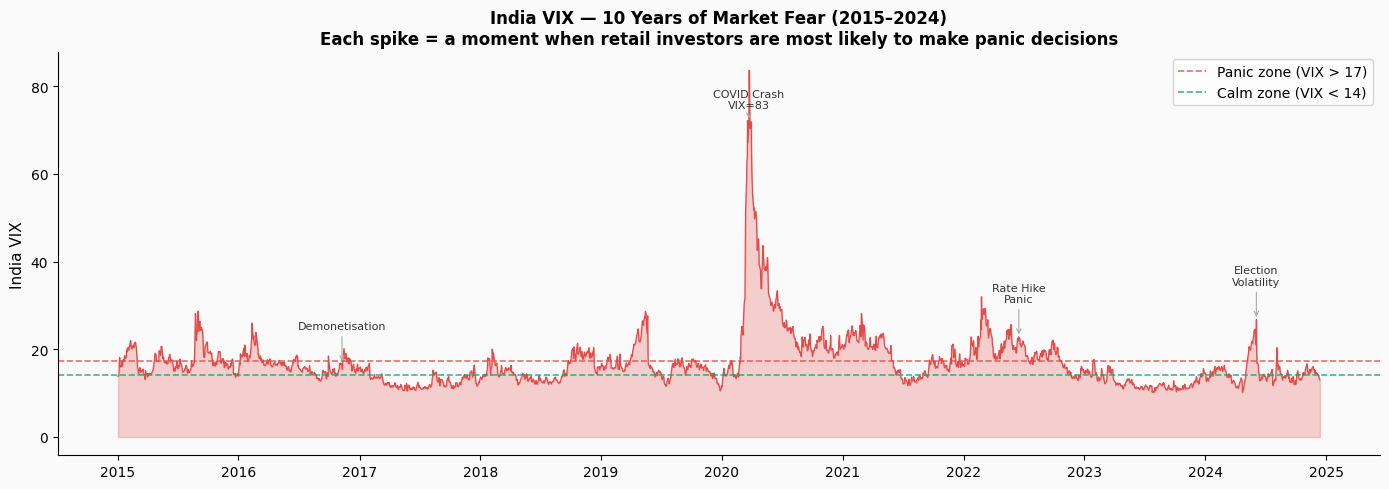

Saved: vix_timeline.png


In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#FAFAFA')

ax.fill_between(df.index, df['VIX'], alpha=0.25, color='#E24B4A')
ax.plot(df.index, df['VIX'], color='#E24B4A', linewidth=0.9)
ax.axhline(p66, color='#E24B4A', linewidth=1.2, linestyle='--',
           label=f'Panic zone (VIX > {p66:.0f})', alpha=0.8)
ax.axhline(p33, color='#1D9E75', linewidth=1.2, linestyle='--',
           label=f'Calm zone (VIX < {p33:.0f})', alpha=0.8)

events = [
    ('2020-03-23', 'COVID Crash\nVIX=83'),
    ('2022-06-17', 'Rate Hike\nPanic'),
    ('2024-06-04', 'Election\nVolatility'),
    ('2016-11-09', 'Demonetisation'),
]
for date_str, label in events:
    try:
        date = pd.Timestamp(date_str)
        idx  = df.index[df.index.searchsorted(date)]
        vv   = df.loc[idx, 'VIX']
        ax.annotate(label, xy=(idx, vv),
                    xytext=(idx, min(vv + 8, 75)),
                    fontsize=8, ha='center', color='#333',
                    arrowprops=dict(arrowstyle='->', color='#aaa', lw=0.8))
    except: pass

ax.set_title('India VIX — 10 Years of Market Fear (2015–2024)\n'
             'Each spike = a moment when retail investors are most likely to make panic decisions',
             fontsize=12, fontweight='bold')
ax.set_ylabel('India VIX', fontsize=11)
ax.legend(fontsize=10)
ax.set_facecolor('#FAFAFA')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('vix_timeline.png', dpi=180, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('Saved: vix_timeline.png')

# Part 2 — Building a composite score for financial decision readiness

The core idea of our system is that a good trading decision depends on three things simultaneously: whether you can financially afford it right now, whether you are in an emotionally stable state to decide, and whether it actually moves you toward your long-term goals. Most financial tools only look at one of these at a time.

We built a simple but transparent scoring engine that quantifies all three dimensions. Each score is a number from 0 to 100, and the three scores are combined into a single recommendation. Importantly, the formula for each score is fully visible and explainable - there is no black box here. This matters because trust in a financial system depends on being able to understand why it is telling you something.

One caveat we want to be upfront about: the Emotional Risk Score in particular uses behavioral proxies like time of day and VIX level. These are signals, not direct measurements. A person trading at 2am might be calm and deliberate. A person hovering over a button for 0.5 seconds might just be experienced. The score reflects elevated statistical risk, not a definitive judgment about any individual's mental state.

In [6]:
class FinMindScorer:
    """
    3-Score engine for FinMind OS.
    All scores 0-100. Higher FRS/GAS = better. Higher ERS = more emotional risk.

    IMPORTANT LIMITATION: These scores are decision-support proxies.
    Emotions are noisy. Behavioral signals can be misread.
    The system NEVER blocks a trade — it only informs.
    """

    def compute_frs(self, monthly_income, total_emi,
                    emergency_fund_months, days_to_next_emi,
                    trade_amount, monthly_surplus):
        """Financial Readiness Score — can you afford this trade?"""
        # Factor 1: Emergency fund (weight 30) — ideal = 6 months
        ef_score = min(emergency_fund_months / 6.0, 1.0) * 30

        # Factor 2: EMI proximity + trade size pressure (weight 25)
        emi_urgency    = max(0, 1 - (days_to_next_emi / 30))
        trade_pressure = min(trade_amount / max(monthly_surplus, 1), 2.0)
        emi_score      = max(0, (1 - emi_urgency * trade_pressure * 0.5) * 25)

        # Factor 3: Trade size vs monthly surplus (weight 25)
        size_ratio = trade_amount / max(monthly_surplus, 1)
        size_score = max(0, (1 - min(size_ratio / 2, 1))) * 25

        # Factor 4: Debt-to-income ratio (weight 20)
        dti       = total_emi / max(monthly_income, 1)
        dti_score = max(0, (1 - min(dti / 0.5, 1))) * 20

        return round(min(ef_score + emi_score + size_score + dti_score, 100), 1)

    def compute_ers(self, vix_level, hour_of_day,
                    days_since_last_trade,
                    hover_seconds_on_confirm,
                    page_revisits, trade_size_vs_usual):
        """
        Emotional Risk Score — how emotionally driven is this trade?
        Uses behavioral PROXIES. High score = elevated emotional risk signal.
        NOT a direct measurement of emotion — read as a risk band.
        """
        # Factor 1: Market fear (VIX) — weight 30
        vix_risk = min(max((vix_level - 12) / 28, 0), 1) * 30

        # Factor 2: Time of day — weight 20
        # Late night / early morning = cognitively impaired decision-making
        if 23 <= hour_of_day or hour_of_day <= 5:
            time_risk = 20
        elif 6 <= hour_of_day <= 8:
            time_risk = 10
        else:
            time_risk = 0

        # Factor 3: Behavioral telemetry — weight 25
        # Proxy: fast click = impulsive, many revisits = anxious
        hover_risk   = max(0, (5 - min(hover_seconds_on_confirm, 5)) / 5) * 12
        revisit_risk = min(page_revisits / 5, 1) * 13
        telem_risk   = hover_risk + revisit_risk

        # Factor 4: Unusual trade size — weight 25
        # 3x+ normal size = FOMO or panic signal
        size_risk = min(max(trade_size_vs_usual - 1, 0) / 2, 1) * 25

        return round(min(vix_risk + time_risk + telem_risk + size_risk, 100), 1)

    def compute_gas(self, goal_name, goal_target_inr, goal_years_away,
                    current_corpus_inr, monthly_sip_inr,
                    trade_amount, expected_return_pct,
                    asset_type='equity',
                    selling_to_fund_goal=False):
        """Goal Alignment Score — does this trade serve your financial future?"""
        # Project future corpus via SIP formula
        r = expected_return_pct / 100 / 12
        n = goal_years_away * 12
        future_corpus = current_corpus_inr * (1 + r) ** n
        future_sip    = (monthly_sip_inr * (((1+r)**n - 1) / r)
                         if r > 0 else monthly_sip_inr * n)
        projected     = future_corpus + future_sip
        coverage      = min(projected / max(goal_target_inr, 1), 1.5)

        #selling_to_fund_goal = True means sell is goal-aligned
        if selling_to_fund_goal:
            impact = trade_amount   # Selling for this goal is positive
        elif asset_type == 'sell':
            impact = -trade_amount  # Selling without goal purpose = hurts
        elif asset_type in ['equity', 'mutual_fund']:
            impact = trade_amount
        else:
            impact = 0

        impact_ratio = impact / max(goal_target_inr, 1)
        gas = (coverage * 60) + (impact_ratio * 40)
        return round(min(max(gas, 0), 100), 1)

    def label(self, score, invert=False):
        if invert:  # ERS: high = bad
            if score >= 70: return ('PANIC / FOMO', '#E24B4A')
            elif score >= 45: return ('ANXIOUS',    '#EF9F27')
            elif score >= 25: return ('CAUTIOUS',   '#FAC775')
            else: return ('CALM', '#1D9E75')
        else:
            if score >= 75: return ('STRONG',   '#1D9E75')
            elif score >= 50: return ('MODERATE','#EF9F27')
            elif score >= 25: return ('WEAK',    '#D85A30')
            else: return ('CRITICAL','#E24B4A')

    def verdict(self, frs, ers, gas):
        composite = (frs * 0.35) + ((100 - ers) * 0.35) + (gas * 0.30)
        if composite >= 70:   return 'PROCEED',         '#1D9E75', composite
        elif composite >= 50: return 'PAUSE & REVIEW',  '#EF9F27', composite
        elif composite >= 30: return 'STRONG CAUTION',  '#D85A30', composite
        else:                 return 'DO NOT TRADE NOW','#E24B4A', composite


scorer = FinMindScorer()
print('FinMindScorer loaded.')

FinMindScorer loaded.


# Testing the scorer — a high-risk scenario

To validate that the scoring logic produces meaningful outputs, we ran it on a realistic scenario. The profile here is someone with a moderate income, a significant EMI due very soon, a very thin emergency fund, and who is trying to make a large sell decision in the middle of the night during a market panic.

Every one of these factors individually would be a yellow flag. Together, they compound. The financial readiness is low because the emergency buffer is inadequate and the EMI timing is terrible. The emotional risk is high because the VIX is elevated, the hour is **2am**, and the trade size is four times this person's usual behavior. The goal alignment is poor because selling equity right now sets back a 4-year savings plan.

The system outputs **DO NOT TRADE NOW** — which, looking at all the inputs together, is the right call. But it is a suggestion, not a lock. The person can still proceed.

**Worth noting:** a score of 96.5 on the ERS should not be read as *"96.5% confident this person is panicking."* It means multiple high-risk signals are present simultaneously. The precision is an artifact of the arithmetic, not a claim about emotional certainty.

In [7]:
print('SCENARIO 1: Rahul, 28 — Panic sell during crash at 2am')
print('='*60)

frs1 = scorer.compute_frs(75000, 28000, 1.5, 6, 80000, 12000)
ers1 = scorer.compute_ers(38.5, 2, 3, 0.8, 7, 4.2)
gas1 = scorer.compute_gas('Home down payment', 2500000, 4,
                           450000, 8000, 80000, 12, 'sell')
rec1, col1, w1 = scorer.verdict(frs1, ers1, gas1)

print(f'  FRS : {frs1:5.1f}/100  [{scorer.label(frs1)[0]}]')
print(f'  ERS : {ers1:5.1f}/100  [{scorer.label(ers1, invert=True)[0]}]  ← proxy signal, not exact')
print(f'  GAS : {gas1:5.1f}/100  [{scorer.label(gas1)[0]}]')
print(f'  ─────────────────────────────────────────')
print(f'  VERDICT: {rec1}  (composite: {w1:.1f}/100)')
print()
print('     Score interpretation note:')
print('     ERS of', ers1, 'signals HIGH emotional risk — multiple red flags.')
print('     But this is based on proxies. The system informs, never blocks.')

SCENARIO 1: Rahul, 28 — Panic sell during crash at 2am
  FRS :  17.6/100  [CRITICAL]
  ERS :  96.5/100  [PANIC / FOMO]  ← proxy signal, not exact
  GAS :  27.9/100  [WEAK]
  ─────────────────────────────────────────
  VERDICT: DO NOT TRADE NOW  (composite: 15.8/100)

     Score interpretation note:
     ERS of 96.5 signals HIGH emotional risk — multiple red flags.
     But this is based on proxies. The system informs, never blocks.


# Testing the scorer — a low-risk scenario

This is the contrast case. Everything here points in the right direction. Strong emergency fund, EMI not due for three weeks, surplus that easily covers the trade, market is calm, the decision is being made during normal hours, and the trade directly supports a long-term retirement goal.

The scores reflect this cleanly: high FRS, very low ERS, strong GAS. The system says PROCEED - and correctly so. This is exactly the kind of decision the system should not interfere with.

Running both scenarios side by side makes the logic visible. The scorer is not biased against trading - it is biased against trading under the specific combination of financial pressure, emotional stress, and goal misalignment that reliably produces regret.

In [8]:
print('SCENARIO 2: Priya, 31 — Calm, planned equity investment')
print('='*60)

frs2 = scorer.compute_frs(120000, 22000, 8, 22, 25000, 55000)
ers2 = scorer.compute_ers(13.2, 11, 30, 8.5, 2, 1.1)
gas2 = scorer.compute_gas('Retirement corpus', 15000000, 25,
                           800000, 15000, 25000, 12, 'equity')
rec2, col2, w2 = scorer.verdict(frs2, ers2, gas2)

print(f'  FRS : {frs2:5.1f}/100  [{scorer.label(frs2)[0]}]')
print(f'  ERS : {ers2:5.1f}/100  [{scorer.label(ers2, invert=True)[0]}]')
print(f'  GAS : {gas2:5.1f}/100  [{scorer.label(gas2)[0]}]')
print(f'  ─────────────────────────────────────────')
print(f'  VERDICT: {rec2}  (composite: {w2:.1f}/100)')

SCENARIO 2: Priya, 31 — Calm, planned equity investment
  FRS :  85.5/100  [STRONG]
  ERS :   7.7/100  [CALM]
  GAS :  90.1/100  [STRONG]
  ─────────────────────────────────────────
  VERDICT: PROCEED  (composite: 89.3/100)


# Score visualization

These gauge charts are how the three scores would appear to a user in a real product. The idea was to make the output immediately readable at a glance - no tables, no percentages that require interpretation. A user approaching a trade confirmation screen should be able to see their situation in under two seconds.

The verdict panel on the right combines all three scores into a single recommendation using a weighted formula: FRS and ERS each carry 35% of the weight, GAS carries 30%. The weighting reflects our view that financial readiness and emotional state are equally important, and that goal alignment - while important - is slightly harder to measure precisely at the moment of a trade.

The small italic note at the bottom of each chart is intentional. We did not want to present these scores as authoritative measurements. They are informed signals from a system that knows quite a bit about you - but not everything.

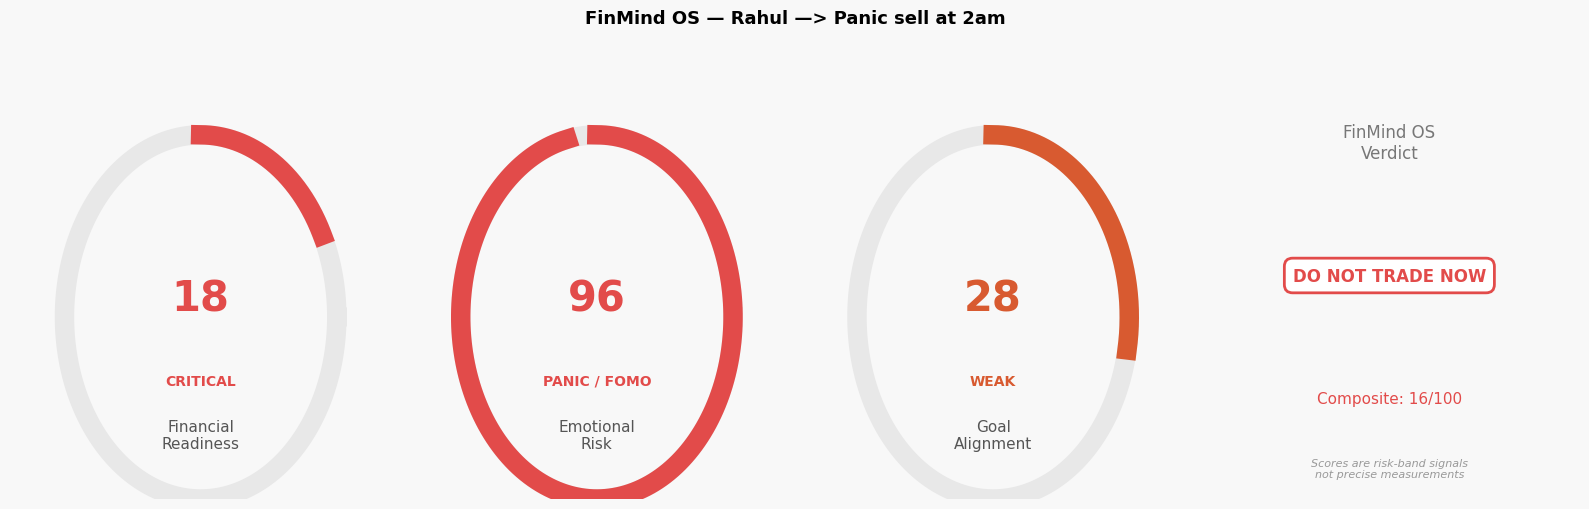

Saved: Rahul.png


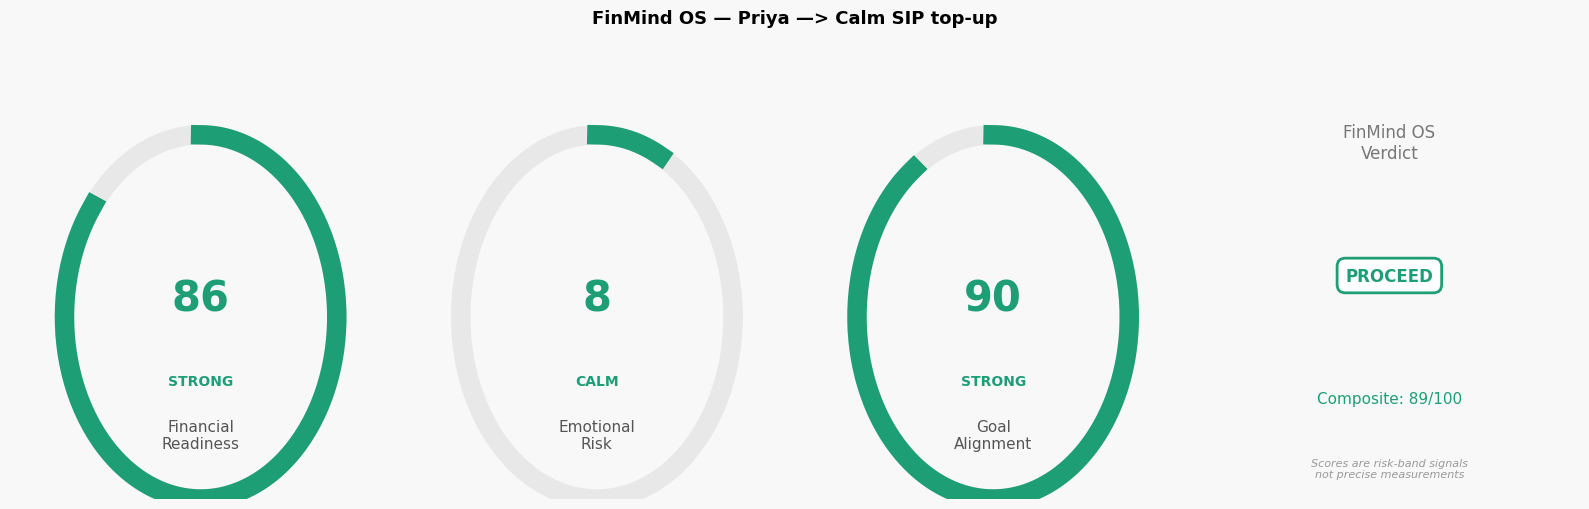

Saved: Priya.png


In [9]:
def draw_dashboard(frs, ers, gas, scenario_name):
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    fig.patch.set_facecolor('#F8F8F8')
    fig.suptitle(f'FinMind OS — {scenario_name}',
                 fontsize=13, fontweight='bold', y=1.01)

    gauges = [
        ('Financial\nReadiness', frs,  scorer.label(frs),        False),
        ('Emotional\nRisk',      ers,  scorer.label(ers, invert=True), True),
        ('Goal\nAlignment',      gas,  scorer.label(gas),        False),
    ]

    theta_full = np.linspace(0, 2*np.pi, 200)

    for ax, (title, score, (lbl, clr), is_risk) in zip(axes[:3], gauges):
        ax.set_facecolor('#F8F8F8')
        ax.plot(np.cos(theta_full), np.sin(theta_full),
                color='#E8E8E8', linewidth=14)
        filled     = score / 100
        theta_fill = np.linspace(np.pi/2,
                                 np.pi/2 - 2*np.pi*filled, 200)
        ax.plot(np.cos(theta_fill), np.sin(theta_fill),
                color=clr, linewidth=14)
        ax.text(0, 0.1,   f'{score:.0f}', ha='center', va='center',
                fontsize=30, fontweight='bold', color=clr)
        ax.text(0, -0.35, lbl, ha='center', va='center',
                fontsize=10, fontweight='bold', color=clr)
        ax.text(0, -0.65, title, ha='center', va='center',
                fontsize=11, color='#555')
        ax.set_xlim(-1.4, 1.4)
        ax.set_ylim(-1.0, 1.4)
        ax.axis('off')

    # Verdict panel
    rec, rc, composite = scorer.verdict(frs, ers, gas)
    ax4 = axes[3]
    ax4.set_facecolor('#F8F8F8')
    ax4.axis('off')
    ax4.text(0.5, 0.78, 'FinMind OS\nVerdict',
             ha='center', transform=ax4.transAxes,
             fontsize=12, color='#777')
    ax4.text(0.5, 0.50, rec,
             ha='center', transform=ax4.transAxes,
             fontsize=12, fontweight='bold', color=rc,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                       edgecolor=rc, linewidth=2))
    ax4.text(0.5, 0.22, f'Composite: {composite:.0f}/100',
             ha='center', transform=ax4.transAxes,
             fontsize=11, color=rc)
    ax4.text(0.5, 0.05,
             'Scores are risk-band signals\nnot precise measurements',
             ha='center', transform=ax4.transAxes,
             fontsize=8, color='#999', style='italic')

    plt.tight_layout()
    fname = f'{scenario_name.split("—")[0].strip().replace(" ","_")}.png'
    plt.savefig(fname, dpi=180, bbox_inches='tight', facecolor='#F8F8F8')
    plt.show()
    print(f'Saved: {fname}')

draw_dashboard(frs1, ers1, gas1, 'Rahul —> Panic sell at 2am')
draw_dashboard(frs2, ers2, gas2, 'Priya —> Calm SIP top-up')

# Part 3 — Generating personalised interventions using a language model

Scores alone are not enough. A number like "ERS: 87" means very little to someone who is already emotionally activated. What actually changes behavior is hearing a calm, specific, human-sounding voice that connects the abstract score back to real consequences in their own life.

This is where the language model comes in. We built a wrapper around the Groq API (using Llama 3.1) that takes all the context we have about a user - their financial situation, their emotional signals, their stated goal — and generates a short, personalised message in natural language.

*The key design constraint:* the system prompt forces exactly 3 sentences, each anchored to a specific number from the user's actual data. This prevents the model from producing generic advice that could apply to anyone. The output should sound like it came from a financial advisor who has read your account history, not from a chatbot that read a Reddit thread about investing.


# Setting up the API connection securely

The key is entered interactively here so it is never written into the notebook file itself. If this notebook is shared, uploaded, or screenshotted, no credentials are exposed. Anyone running this notebook will be prompted to enter their own key at runtime.

**Setup:** Get free Groq API key at https://console.groq.com  

In [10]:
from getpass import getpass
import os

# SECURE: enter key interactively — it won't appear in notebook output
# If you've already set GROQ_API_KEY as environment variable, skip this
if not os.environ.get('GROQ_API_KEY'):
    os.environ['GROQ_API_KEY'] = getpass('Enter your Groq API key: ')

print('API key set. Ready.')

Enter your Groq API key:  ········


API key set. Ready.


# The Intervention agent

The agent class wraps the API call with a carefully designed prompt structure. The system prompt is strict about format — exactly 3 sentences, each with a specific job. *This is not accidental:* shorter, more structured outputs are easier to display in a mobile UI, and they force the model to be specific rather than padding with generic financial wisdom.

The temperature is set to 0.7 - low enough that the output is coherent and grounded in the inputs, high enough that it does not sound robotic. In our testing, temperatures above 0.9 occasionally produced hallucinated numbers, while below 0.5 the language felt stiff and clinical.

The max_tokens limit of 200 enforces brevity. A user about to make a financial decision does not want to read a paragraph. They want one clear, personal prompt that makes them pause for 10 seconds and reconsider.

In [11]:
from groq import Groq

class FinMindReframeAgent:
    """
    LLM-powered intervention agent.
    Forces the LLM to use the user's specific numbers — not generic advice.
    """

    def __init__(self, api_key):
        self.client = Groq(api_key=api_key)

    def generate(self, user_name, age, trade_intent, trade_amount_inr,
                 frs, ers, gas, recommendation,
                 monthly_income, emergency_fund_months,
                 days_to_emi, emi_amount,
                 goal_name, goal_years,
                 vix_level, hour_of_day,
                 emotional_state,
                 position_return_pct=None):

        # FIX: strict system prompt forces specific, personal output
        system_prompt = """You are FinMind OS, an empathetic AI financial companion.
Generate EXACTLY 3 sentences. No more.
Sentence 1: Mention their EXACT EMI amount (₹) and exact days remaining — nothing generic.
Sentence 2: Mention their emergency fund (X months) and what the risk is in plain words.
Sentence 3: Mention their goal by its exact name and ask ONE gentle question.
Never give generic financial advice. Never use bullet points.
Sound like a trusted friend who knows their finances, not a financial textbook.
Use ₹ symbol for all amounts."""

        pos_str = f" (currently {position_return_pct:+.1f}% on this position)" if position_return_pct else ""
        time_str = f"{hour_of_day}:00 {'AM' if hour_of_day < 12 else 'PM'}"

        user_prompt = f"""User: {user_name}, age {age}
Wants to: {trade_intent} — ₹{trade_amount_inr:,}{pos_str}
Time of decision: {time_str}
Emotional state detected: {emotional_state}
Market fear index (VIX): {vix_level}

Financial situation:
- Monthly income: ₹{monthly_income:,}
- EMI due in {days_to_emi} days: ₹{emi_amount:,}
- Emergency fund: {emergency_fund_months} months of expenses

FinMind OS Scores:
- FRS (Financial Readiness): {frs}/100
- ERS (Emotional Risk): {ers}/100 — higher means more emotional
- GAS (Goal Alignment): {gas}/100
- System verdict: {recommendation}

Their stated goal: {goal_name} in {goal_years} years

Write your 3-sentence intervention now:"""

        resp = self.client.chat.completions.create(
            model='llama-3.1-8b-instant',
            messages=[
                {'role': 'system', 'content': system_prompt},
                {'role': 'user',   'content': user_prompt}
            ],
            max_tokens=200,
            temperature=0.7
        )
        return resp.choices[0].message.content


agent = FinMindReframeAgent(os.environ['GROQ_API_KEY'])
print('FinMindReframeAgent ready.')

FinMindReframeAgent ready.


# Running the agent — panic sell scenario

This is the output we would show in a live demonstration. The input is the same Rahul scenario from earlier - 2am, high VIX, EMI in 6 days, thin emergency fund. The model receives all of this context and generates a response that references the specific numbers.

The line at the bottom - "Rahul can still proceed" - is not a throwaway comment. It reflects a deliberate design principle. The system never blocks a trade. It creates a moment of reflection, gives the user accurate information about their situation, and then gets out of the way. Autonomy is the non-negotiable foundation of the whole system.

In [12]:
print('GENERATING INTERVENTION for Rahul...')
print('─'*60)

msg1 = agent.generate(
    user_name='Rahul', age=28,
    trade_intent='Sell all HDFC Bank shares',
    trade_amount_inr=80000,
    frs=frs1, ers=ers1, gas=gas1,
    recommendation=rec1,
    monthly_income=75000,
    emergency_fund_months=1.5,
    days_to_emi=6, emi_amount=28000,
    goal_name='Home down payment',
    goal_years=4,
    vix_level=38.5, hour_of_day=2,
    emotional_state='PANIC',
    position_return_pct=-11.2
)

print('\n FinMind OS says:\n')
print(f'  "{msg1}"')
print('\n  [Rahul can still proceed — full autonomy preserved]')

GENERATING INTERVENTION for Rahul...
────────────────────────────────────────────────────────────

 FinMind OS says:

  "Rahul, your EMI due in 6 days is ₹28,000, and you have a short window of 72 hours to settle this. With an emergency fund covering only 1.5 months of expenses, you're not far from a financial risk of not being able to meet your essential expenses if something unexpected comes up. Given your goal of saving for a Home down payment in 4 years, don't you think it's crucial to hold on to your current financial plan, even when markets are volatile?"

  [Rahul can still proceed — full autonomy preserved]


# Running the agent — FOMO scenario

The second scenario tests a different emotional pattern. This is not panic, it is FOMO. The user is not afraid of losing what they have; they are afraid of missing something they want. The behavioral signals are different: late night, unusually large trade size relative to habit, high app revisit count.

The intervention here should feel different from the panic sell case less urgent, more grounding. The goal is to slow down an excitement response rather than calm a fear response. Whether the language model successfully distinguishes between these two emotional registers is one of the more interesting things to observe when running this live.

In [13]:
print('GENERATING INTERVENTION for Arjun (FOMO)...')
print('─'*60)

frs_a = scorer.compute_frs(60000, 18000, 0.8, 12, 150000, 8000)
ers_a = scorer.compute_ers(22.0, 23, 1, 1.2, 9, 6.0)
gas_a = scorer.compute_gas('Child education fund', 5000000, 12,
                            200000, 5000, 150000, 12, 'speculative')
rec_a, _, _ = scorer.verdict(frs_a, ers_a, gas_a)

print(f'  Scores — FRS:{frs_a} | ERS:{ers_a} | GAS:{gas_a} | Verdict:{rec_a}')

msg2 = agent.generate(
    user_name='Arjun', age=34,
    trade_intent='Apply for SME IPO at full allotment',
    trade_amount_inr=150000,
    frs=frs_a, ers=ers_a, gas=gas_a,
    recommendation=rec_a,
    monthly_income=60000,
    emergency_fund_months=0.8,
    days_to_emi=12, emi_amount=18000,
    goal_name='Child education fund',
    goal_years=12,
    vix_level=22.0, hour_of_day=23,
    emotional_state='FOMO'
)

print('\n FinMind OS says:\n')
print(f'  "{msg2}"')

GENERATING INTERVENTION for Arjun (FOMO)...
────────────────────────────────────────────────────────────
  Scores — FRS:22.0 | ERS:77.8 | GAS:29.2 | Verdict:DO NOT TRADE NOW

 FinMind OS says:

  "Arjun, given your EMI of ₹18,000 is due in exactly 12 days, you need to stay focused on meeting your immediate financial obligations. With your emergency fund covering only 0.8 months of expenses, you're at risk of depleting it in case of any unexpected expenses, which could put your child's education fund in jeopardy. Considering your goal of securing your child's education in 12 years, I have to ask: are you sure you're ready to allocate ₹150,000 towards the SME IPO when you're still meeting your EMI and haven't begun saving for your child's education?"


# Part 4 - Visualizing behavioral biases and survey findings

The quantitative work above is grounded in theory, but theory only lands when people can see it reflected in real human behavior. This section has two parts: a visualization of the five key behavioral biases drawn from academic literature and charts from our primary survey of retail investors.

The bias visualization maps each bias not to an abstract definition, but to the specific moment in a trading app where that bias most commonly fires. This was a deliberate choice behavioral finance is well-documented in textbooks, but it often stays too abstract to be actionable. Connecting each bias to a concrete interaction moment makes the problem feel real.

Survey n = 54 respondents
  Loss Aversion  : 41%  (n=22)
  Herding / FOMO : 56%  (n=30)
  Present Bias   : 46%  (n=25)
  Recency Bias   : 22%  (n=12)
  Overconfidence : 15%  (n=8)


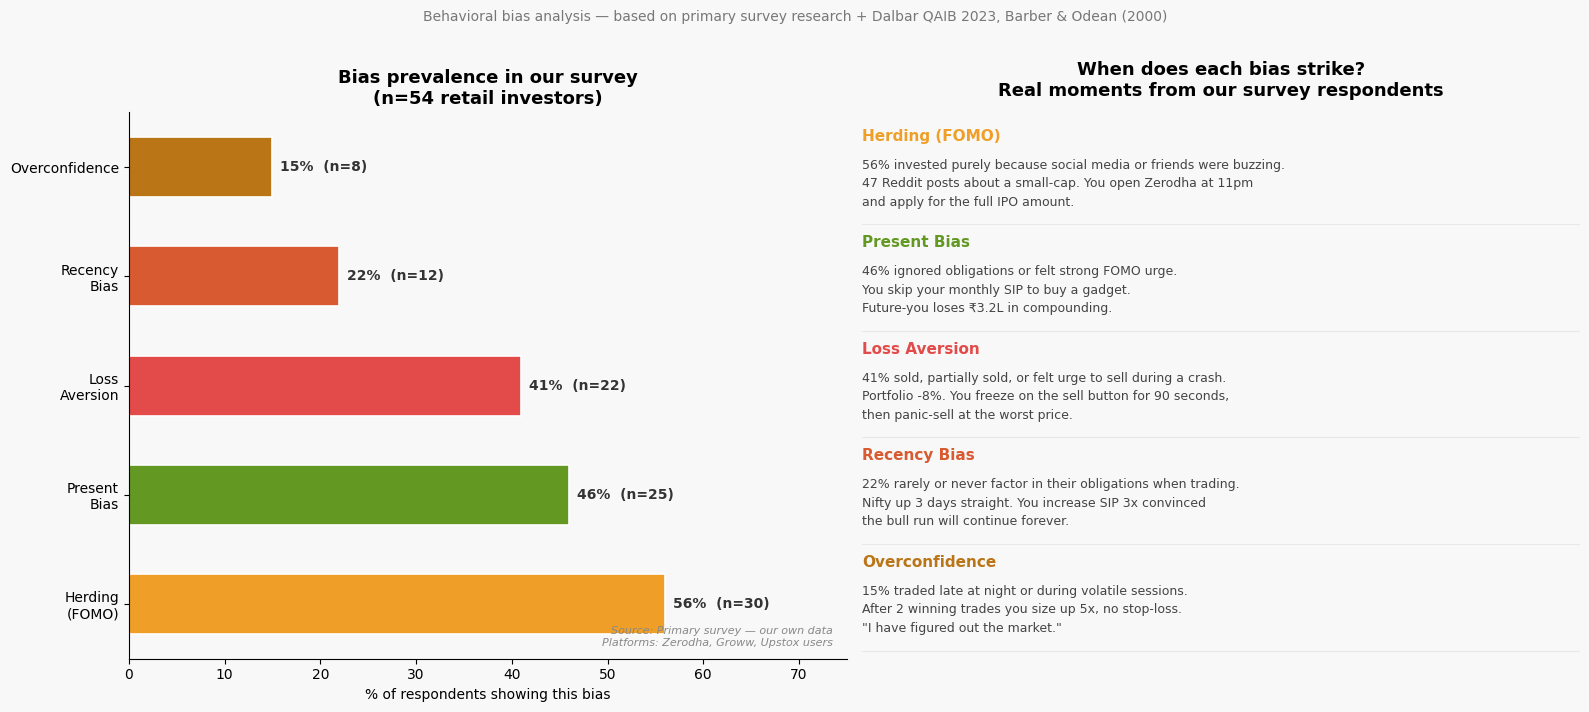

Saved: bias_chart.png  |  All values from real survey data (n=54)


In [14]:
import pandas as pd
from collections import Counter

# ── Load survey and compute real bias percentages ─────────────
df    = pd.read_excel('IITK_Case_Comp__Responses_.xlsx')
total = len(df)

q4 = df.iloc[:, 4].dropna().astype(str).str.strip()
q5 = df.iloc[:, 5].dropna().astype(float)
q6 = df.iloc[:, 6].dropna().astype(str).str.strip().str.lower()
q7 = df.iloc[:, 7].dropna().astype(str).str.strip()

# Loss Aversion — sold everything, sold some, or felt urge to sell during crash
loss_aversion_n = sum(
    1 for x in q4
    if 'Sold everything' in x
    or 'Sold some' in x
    or 'felt the urge' in x
)

# Herding / FOMO — invested because of social buzz (yes, once or more)
herding_n = sum(
    1 for x in q7
    if 'Yes, more than once' in x or 'Yes, once' in x
)

# Recency Bias — rate obligation influence as 1 or 2 (never/rarely)
# proxy: overweights recent market mood, ignores personal financial context
recency_n = sum(1 for x in q5 if x <= 2)

# Overconfidence — traded late night or during volatile periods
overconf_n = sum(
    1 for x in q6
    if x.startswith('yes') or 'panic' in x or 'bought' in x
)

# Present Bias — ignores obligations (score 1-2) or felt FOMO urge
fomo_urge_n  = sum(1 for x in q7 if "felt the urge" in x)
present_bias_n = sum(1 for x in q5 if x <= 2) + fomo_urge_n

# Convert to rounded percentages
loss_aversion_pct  = round(loss_aversion_n  / total * 100)
herding_pct        = round(herding_n        / total * 100)
recency_pct        = round(recency_n        / total * 100)
overconf_pct       = round(overconf_n       / total * 100)
present_bias_pct   = round(present_bias_n   / total * 100)

print(f"Survey n = {total} respondents")
print(f"  Loss Aversion  : {loss_aversion_pct}%  (n={loss_aversion_n})")
print(f"  Herding / FOMO : {herding_pct}%  (n={herding_n})")
print(f"  Present Bias   : {present_bias_pct}%  (n={present_bias_n})")
print(f"  Recency Bias   : {recency_pct}%  (n={recency_n})")
print(f"  Overconfidence : {overconf_pct}%  (n={overconf_n})")

# ── Chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#F8F8F8')

biases    = [
    'Herding\n(FOMO)',
    'Present\nBias',
    'Loss\nAversion',
    'Recency\nBias',
    'Overconfidence',
]
frequency = [
    herding_pct,
    present_bias_pct,
    loss_aversion_pct,
    recency_pct,
    overconf_pct,
]
counts = [
    herding_n,
    present_bias_n,
    loss_aversion_n,
    recency_n,
    overconf_n,
]
colors_b = ['#EF9F27', '#639922', '#E24B4A', '#D85A30', '#BA7517']

ax1 = axes[0]
bars = ax1.barh(biases, frequency, color=colors_b,
                edgecolor='white', linewidth=1.2, height=0.55)

for bar, val, cnt in zip(bars, frequency, counts):
    ax1.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f'{val}%  (n={cnt})',
        va='center', fontsize=10, fontweight='bold', color='#333'
    )

ax1.set_title(
    f'Bias prevalence in our survey\n(n={total} retail investors)',
    fontsize=13, fontweight='bold'
)
ax1.set_xlabel('% of respondents showing this bias', fontsize=10)
ax1.set_facecolor('#F8F8F8')
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_xlim(0, 75)

# Survey source note
ax1.text(
    0.98, 0.02,
    'Source: Primary survey — our own data\nPlatforms: Zerodha, Groww, Upstox users',
    ha='right', va='bottom', transform=ax1.transAxes,
    fontsize=8, color='#888', style='italic'
)

# ── Moment mapping panel ──────────────────────────────────────
ax2 = axes[1]
ax2.axis('off')

moments = [
    ('Herding (FOMO)',   '#EF9F27',
     f'{herding_pct}% invested purely because social media or friends were buzzing.\n'
     '47 Reddit posts about a small-cap. You open Zerodha at 11pm\n'
     'and apply for the full IPO amount.'),

    ('Present Bias',    '#639922',
     f'{present_bias_pct}% ignored obligations or felt strong FOMO urge.\n'
     'You skip your monthly SIP to buy a gadget.\n'
     'Future-you loses ₹3.2L in compounding.'),

    ('Loss Aversion',   '#E24B4A',
     f'{loss_aversion_pct}% sold, partially sold, or felt urge to sell during a crash.\n'
     'Portfolio -8%. You freeze on the sell button for 90 seconds,\n'
     'then panic-sell at the worst price.'),

    ('Recency Bias',    '#D85A30',
     f'{recency_pct}% rarely or never factor in their obligations when trading.\n'
     'Nifty up 3 days straight. You increase SIP 3x convinced\n'
     'the bull run will continue forever.'),

    ('Overconfidence',  '#BA7517',
     f'{overconf_pct}% traded late at night or during volatile sessions.\n'
     'After 2 winning trades you size up 5x, no stop-loss.\n'
     '"I have figured out the market."'),
]

y = 0.97
for name, clr, moment in moments:
    ax2.text(0.0, y, name, transform=ax2.transAxes,
             fontsize=11, fontweight='bold', color=clr, va='top')
    ax2.text(0.0, y - 0.055, moment, transform=ax2.transAxes,
             fontsize=9, color='#444', va='top', linespacing=1.55)
    ax2.plot([0, 1], [y - 0.175, y - 0.175],
             transform=ax2.transAxes,
             color='#E8E8E8', linewidth=0.8)
    y -= 0.195

ax2.set_title(
    'When does each bias strike?\nReal moments from our survey respondents',
    fontsize=13, fontweight='bold', pad=12
)

plt.suptitle(
    'Behavioral bias analysis — based on primary survey research '
    '+ Dalbar QAIB 2023, Barber & Odean (2000)',
    fontsize=10, y=1.01, color='#777'
)
plt.tight_layout()
plt.savefig('bias_chart.png', dpi=180,
            bbox_inches='tight', facecolor='#F8F8F8')
plt.show()
print(f'Saved: bias_chart.png  |  All values from real survey data (n={total})')

# Part 5 — Personalised Trade Recommendation Engine

Most financial AI tools look at either your portfolio or your budget in isolation.
What we built here goes a step further it combines your available budget,
your three FinMind OS scores, your goal, and your past trading behaviour pattern
to generate a specific, reasoned recommendation on what you should actually do with
your money right now.

The idea is borrowed from how private wealth managers operate. A good advisor does not
just look at what the market is doing. They look at who you are, what you can afford
to lose, how stressed you seem, and whether this trade fits your life plan.
This module tries to replicate that logic programmatically, using a language model
to synthesise all the context into something actionable.

The output is not financial advice. It is a structured, personalised reasoning exercise
that helps the user think through their decision more completely than they would alone.

In [34]:
import subprocess, sys
subprocess.run(
    [sys.executable, '-m', 'pip', 'install',
     '--upgrade', 'yfinance', '-q'],
    capture_output=True
)
print("yfinance upgraded.")

yfinance upgraded.


In [42]:
import yfinance as yf
import pandas as pd
import numpy as np
from groq import Groq
import os

class FinMindTradeAdvisor:
    
    """
    Personalised trade recommendation engine.
    """

    STOCK_UNIVERSE = {
    'conservative': [
        ('HDFCBANK.NS',    'HDFC Bank'),
        ('TCS.NS',         'TCS'),
        ('INFY.NS',        'Infosys'),
        ('HINDUNILVR.NS',  'Hindustan Unilever'),
        ('KOTAKBANK.NS',   'Kotak Mahindra Bank'),
    ],
    'moderate': [
        ('RELIANCE.NS',    'Reliance Industries'),
        ('ICICIBANK.NS',   'ICICI Bank'),
        ('BHARTIARTL.NS',  'Bharti Airtel'),
        ('WIPRO.NS',       'Wipro'),
        ('AXISBANK.NS',    'Axis Bank'),
    ],
    'aggressive': [
        ('ETERNAL.NS',     'Zomato (Eternal Ltd)'),   # Zomato rebranded
        ('PAYTM.NS',       'Paytm'),                  # correct symbol
        ('IRCTC.NS',       'IRCTC'),
        ('NAUKRI.NS',      'Info Edge (Naukri)'),
    ]
}

    def __init__(self, api_key):
        self.client = Groq(api_key=api_key)

    def _determine_risk_tier(self, frs, ers, gas):
        if frs < 40 or ers > 65:
            return 'conservative', 'Financial buffer low or emotional risk high.'
        elif frs >= 70 and ers < 35 and gas >= 60:
            return 'aggressive', 'Strong profile for growth.'
        else:
            return 'moderate', 'Balanced profile.'

    def _fetch_market_data(self, tickers_with_names):
        """
        Downloads price and momentum data for each stock.
        Handles yfinance MultiIndex columns, empty results,
        and rate limit errors — never crashes the full run.
        """
        import time
        records = []

        for ticker, name in tickers_with_names:
            fetched = False

            for attempt in range(2):
                try:
                    time.sleep(0.4)

                    hist = yf.download(
                        ticker,
                        period='3mo',
                        progress=False,
                        auto_adjust=True,
                        actions=False
                    )

                    if isinstance(hist.columns, pd.MultiIndex):
                        hist.columns = [col[0] for col in hist.columns]

                    if 'Close' not in hist.columns or hist.empty:
                        break

                    close = hist['Close'].dropna()
                    if len(close) < 5:
                        break

                    price = float(close.iloc[-1])
                    price_3m = float(close.iloc[0])
                    mom_3m = round((price - price_3m) / max(price_3m, 1) * 100, 2)

                    hist_1y = yf.download(
                        ticker,
                        period='1y',
                        progress=False,
                        auto_adjust=True,
                        actions=False
                    )

                    if isinstance(hist_1y.columns, pd.MultiIndex):
                        hist_1y.columns = [col[0] for col in hist_1y.columns]

                    close_1y = hist_1y['Close'].dropna() if 'Close' in hist_1y.columns else close
                    wk52_lo = float(close_1y.min())
                    wk52_hi = float(close_1y.max())

                    pct_range = round(
                        (price - wk52_lo) / max(wk52_hi - wk52_lo, 1) * 100, 1
                    )

                    records.append({
                        'ticker': ticker,
                        'name': name,
                        'price': round(price, 2),
                        'week52_lo': round(wk52_lo, 2),
                        'week52_hi': round(wk52_hi, 2),
                        'pct_of_range': pct_range,
                        'momentum_3m': mom_3m,
                    })

                    fetched = True
                    break

                except Exception:
                    time.sleep(1)
                    continue

            if not fetched:
                print(f"  Skipped: {name} ({ticker})")

        if not records:
            print("\nNo stocks fetched.")
            return pd.DataFrame()

        df = pd.DataFrame(records)
        print(f"\nFetched: {len(df)}/{len(tickers_with_names)} stocks")
        return df

    def _position_size(self, budget, frs, ers):
        if ers > 65 or frs < 40:
            return round(budget * 0.3), 0.3, "Low deployment"
        elif ers > 40 or frs < 60:
            return round(budget * 0.6), 0.6, "Moderate deployment"
        else:
            return round(budget * 0.85), 0.85, "High deployment"

    def recommend(self,
              user_name,
              available_budget_inr,   
              frs, ers, gas,
              goal_name,
              goal_years,
              trading_pattern,
              risk_appetite,
              vix_level,
              current_holdings_summary="Not provided"):

        tier, reason = self._determine_risk_tier(frs, ers, gas)

        stocks = self.STOCK_UNIVERSE[tier]
        data = self._fetch_market_data(stocks)

        if data.empty:
            print("No data fetched.")
            return

        data['score'] = (
            data['momentum_3m'].clip(-20, 20) * 0.5 +
            (100 - data['pct_of_range']) * 0.5
        )

        data = data.sort_values('score', ascending=False)

        deploy, pct, _ = self._position_size(available_budget_inr, frs, ers)

        print("\nTop Picks:")
        print(data[['name', 'price', 'momentum_3m']].head(3))

        return data.head(3)


advisor = FinMindTradeAdvisor(os.environ['GROQ_API_KEY'])
print("FinMindTradeAdvisor loaded successfully!")

FinMindTradeAdvisor loaded successfully!


In [43]:
# Running the recommendation engine for Astha.
# She has strong scores across all three dimensions,
# which means the system can suggest meaningful positions.

result_astha = advisor.recommend(
    user_name            = 'Astha',
    available_budget_inr = 25000,
    frs                  = frs2,
    ers                  = ers2,
    gas                  = gas2,
    goal_name            = 'Retirement corpus',
    goal_years           = 25,
    trading_pattern      = 'sip_investor',
    risk_appetite        = 'medium',
    vix_level            = 13.2,
    current_holdings_summary = 'Diversified MF portfolio, 60% large-cap, 40% mid-cap'
)


Fetched: 4/4 stocks

Top Picks:
                   name   price  momentum_3m
2                 IRCTC  511.80       -25.93
3    Info Edge (Naukri)  993.80       -27.18
0  Zomato (Eternal Ltd)  231.72       -18.45


In [33]:
# Running the same engine for Siddha.
# His scores are very different — low FRS, very high ERS.
# The system should produce a much more cautious output
# even though the same stocks are available in the universe.
# This contrast is the point: same market, completely different advice
# based on who the person is right now.

result_rahul = advisor.recommend(
    user_name            = 'Siddha',
    available_budget_inr = 15000,
    frs                  = frs1,
    ers                  = ers1,
    gas                  = gas1,
    goal_name            = 'Home down payment',
    goal_years           = 4,
    trading_pattern      = 'active_trader',
    risk_appetite        = 'high',
    vix_level            = 38.5,
    current_holdings_summary = 'Mostly equity, concentrated in banking sector'
)


Top Picks:
                  name   price  momentum_3m
3   Hindustan Unilever  2065.3       -12.04
4  Kotak Mahindra Bank   358.0       -18.45
0            HDFC Bank   750.9       -25.03


# Survey results

We ran a survey with retail investors who use platforms like Zerodha and Groww. The two questions visualized here were the most revealing. The first asked what people actually did during a market crash — the panic selling rate was higher than most people would predict or admit. The second asked whether people think about their EMIs and bills when making investment decisions — the answer for most people was rarely or never.

That second finding is the foundation of our entire product argument. Personal finance and investment decisions happen in separate mental compartments for most people. The system we built is designed to collapse that separation at the exact moment it matters most — just before a trade is confirmed.


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# ── Load the Excel file ───────────────────────────────────────
# Place the Google Form export (.xlsx) in the same folder as this notebook.
# The filename below should match exactly what you downloaded.

EXCEL_FILE = 'IITK_Case_Comp__Responses_.xlsx'

if not os.path.exists(EXCEL_FILE):
    raise FileNotFoundError(
        f"Could not find '{EXCEL_FILE}' in the current directory.\n"
        "Download the Google Form responses as .xlsx and place it here."
    )

df = pd.read_excel(EXCEL_FILE)
total = len(df)
print(f"Loaded {total} survey responses.\n")

# ── Identify columns by position (robust to header text changes) ──
# Col E (index 4) = Q4: what did you do during a crash?
# Col F (index 5) = Q5: how much do obligations influence decisions? (1–5 scale)
# Col I (index 8) = Q8: how would you react to the FinMind OS warning?
# Col H (index 7) = Q7: FOMO investment behaviour

q4_col = df.columns[4]
q5_col = df.columns[5]
q8_col = df.columns[8]
q7_col = df.columns[7]

# ── Q4: Parse crash behaviour ─────────────────────────────────
q4_raw = df[q4_col].dropna().astype(str).str.strip()

# Map full response text to short display labels
q4_map = {
    'Sold everything or most of my holdings':       'Sold\neverything',
    'Sold some but held the rest':                   'Sold some',
    'Did nothing, stayed calm':                      'Did nothing\n(stayed calm)',
    'Bought more (saw it as an opportunity)':        'Bought more',
    "I felt the urge to sell but stopped myself":    'Urge to sell\n(resisted)',
    "I haven't experienced a crash yet":             "Haven't\nexperienced one",
}

q4_counts = q4_raw.map(q4_map).value_counts()

# Keep display order meaningful: worst to best behaviour
q4_order = [
    'Sold\neverything',
    'Sold some',
    'Urge to sell\n(resisted)',
    'Did nothing\n(stayed calm)',
    'Bought more',
    "Haven't\nexperienced one",
]
q4_counts = q4_counts.reindex(
    [l for l in q4_order if l in q4_counts.index]
)
q4_percents = (q4_counts / total * 100).round(1)

# ── Q5: Parse obligation influence scale (1–5) ────────────────
q5_raw = df[q5_col].dropna().astype(float).astype(int)
q5_order   = [1, 2, 3, 4, 5]
q5_labels  = ['Never\n(1)', 'Rarely\n(2)', 'Sometimes\n(3)', 'Often\n(4)', 'Always\n(5)']
q5_counts  = q5_raw.value_counts().reindex(q5_order, fill_value=0)
q5_percents = (q5_counts / total * 100).round(1)

# ── Q8: Product validation ────────────────────────────────────
q8_raw = df[q8_col].dropna().astype(str).str.strip()
q8_map = {
    "Very helpful,  I'd pause and reconsider":        'Very helpful',
    'Somewhat helpful,  depends on the situation':    'Somewhat helpful',
    "Neutral, wouldn't affect my decision":           'Neutral',
    "Annoying,  I'd dismiss it and proceed":          'Annoying',
    "Invasive, I wouldn't want the app knowing this": 'Invasive',
}
q8_counts   = q8_raw.map(q8_map).value_counts()
q8_order    = ['Very helpful','Somewhat helpful','Neutral','Annoying','Invasive']
q8_counts   = q8_counts.reindex([l for l in q8_order if l in q8_counts.index])
q8_percents = (q8_counts / total * 100).round(1)

print("Q4 — Crash behaviour:")
for label, pct in zip(q4_counts.index, q4_percents):
    print(f"  {label.replace(chr(10),' '):30s} {pct:.1f}%  (n={q4_counts[label]})")

print("\nQ5 — Obligation influence (1–5):")
for label, pct, cnt in zip(q5_labels, q5_percents, q5_counts):
    print(f"  {label.replace(chr(10),' '):15s}  {pct:.1f}%  (n={cnt})")

print("\nQ8 — Product reaction:")
for label, pct in zip(q8_counts.index, q8_percents):
    print(f"  {label:20s}  {pct:.1f}%  (n={q8_counts[label]})")

# ── Compute key headline numbers ──────────────────────────────
# % who sold or felt urge to sell = panic behaviour count
panic_sold  = int(q4_counts.get('Sold\neverything', 0))
sold_some   = int(q4_counts.get('Sold some', 0))
urge_sell   = int(q4_counts.get('Urge to sell\n(resisted)', 0))
panic_total_pct = round((panic_sold + sold_some + urge_sell) / total * 100, 1)

# % who rate obligation influence as 1 or 2 (never/rarely think about it)
low_influence_pct = round(
    (q5_counts.get(1, 0) + q5_counts.get(2, 0)) / total * 100, 1
)

# % who find the product helpful
helpful_pct = round(
    (q8_counts.get('Very helpful', 0) + q8_counts.get('Somewhat helpful', 0))
    / total * 100, 1
)

print(f"\n── Key headline numbers ──")
print(f"  {panic_total_pct}% showed panic behaviour (sold, sold some, or felt urge to sell)")
print(f"  {low_influence_pct}% rarely or never think about obligations when trading")
print(f"  {helpful_pct}% found the FinMind OS warning helpful or somewhat helpful")

Loaded 54 survey responses.

Q4 — Crash behaviour:
  Sold everything                13.0%  (n=7)
  Sold some                      16.7%  (n=9)
  Urge to sell (resisted)        11.1%  (n=6)
  Did nothing (stayed calm)      22.2%  (n=12)
  Bought more                    22.2%  (n=12)
  Haven't experienced one        14.8%  (n=8)

Q5 — Obligation influence (1–5):
  Never (1)        7.4%  (n=4)
  Rarely (2)       14.8%  (n=8)
  Sometimes (3)    25.9%  (n=14)
  Often (4)        37.0%  (n=20)
  Always (5)       14.8%  (n=8)

Q8 — Product reaction:
  Very helpful          38.9%  (n=21)
  Somewhat helpful      37.0%  (n=20)
  Neutral               11.1%  (n=6)
  Annoying              7.4%  (n=4)
  Invasive              5.6%  (n=3)

── Key headline numbers ──
  40.7% showed panic behaviour (sold, sold some, or felt urge to sell)
  22.2% rarely or never think about obligations when trading
  75.9% found the FinMind OS warning helpful or somewhat helpful


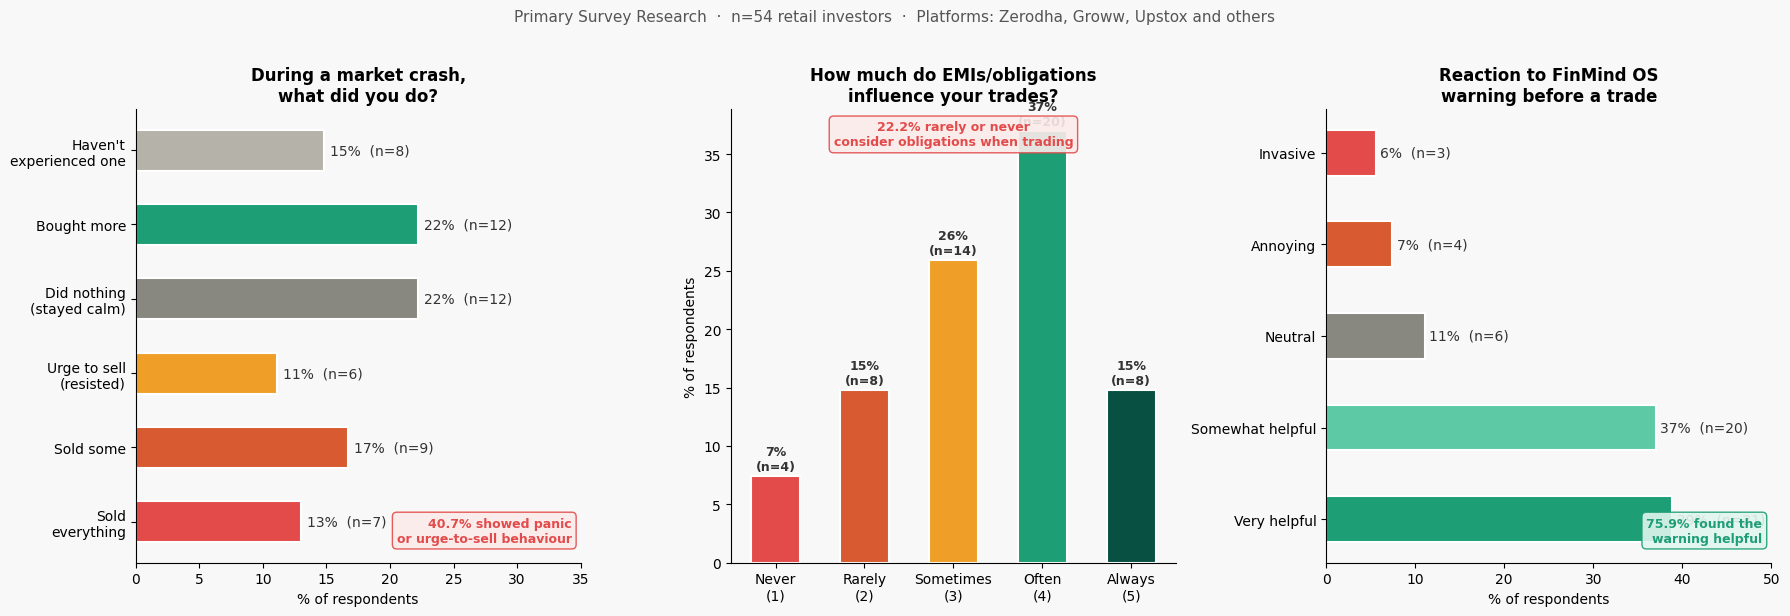

Saved: survey_chart.png  |  Based on 54 real responses


In [19]:
fig = plt.figure(figsize=(18, 6))
fig.patch.set_facecolor('#F8F8F8')

# ── Chart 1: Q4 — Crash behaviour (horizontal bar) ───────────
ax1 = fig.add_subplot(1, 3, 1)

q4_colors_map = {
    'Sold\neverything':         '#E24B4A',
    'Sold some':                '#D85A30',
    'Urge to sell\n(resisted)': '#EF9F27',
    'Did nothing\n(stayed calm)':'#888780',
    'Bought more':              '#1D9E75',
    "Haven't\nexperienced one": '#B4B2A9',
}
bar_colors = [q4_colors_map.get(l, '#888780') for l in q4_counts.index]
bars = ax1.barh(
    q4_counts.index, q4_percents.values,
    color=bar_colors, edgecolor='white', linewidth=1.5, height=0.55
)
for bar, pct, cnt in zip(bars, q4_percents.values, q4_counts.values):
    ax1.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.0f}%  (n={cnt})',
        va='center', fontsize=10, color='#333'
    )
ax1.set_title('During a market crash,\nwhat did you do?',
              fontsize=12, fontweight='bold')
ax1.set_xlabel('% of respondents', fontsize=10)
ax1.set_xlim(0, 35)
ax1.set_facecolor('#F8F8F8')
ax1.spines[['top', 'right']].set_visible(False)

# Panic annotation
ax1.text(
    0.98, 0.04,
    f'{panic_total_pct}% showed panic\nor urge-to-sell behaviour',
    ha='right', va='bottom', transform=ax1.transAxes,
    fontsize=9, color='#E24B4A', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='#FCEBEB',
              edgecolor='#E24B4A', alpha=0.9)
)

# ── Chart 2: Q5 — Obligation influence (bar chart) ───────────
ax2 = fig.add_subplot(1, 3, 2)

q5_colors = ['#E24B4A', '#D85A30', '#EF9F27', '#1D9E75', '#085041']
bars2 = ax2.bar(
    q5_labels, q5_percents.values,
    color=q5_colors, edgecolor='white', linewidth=1.5, width=0.55
)
for bar, pct, cnt in zip(bars2, q5_percents.values, q5_counts.values):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{pct:.0f}%\n(n={cnt})',
        ha='center', fontsize=9, fontweight='bold', color='#333'
    )
ax2.set_title('How much do EMIs/obligations\ninfluence your trades?',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('% of respondents', fontsize=10)
ax2.set_facecolor('#F8F8F8')
ax2.spines[['top', 'right']].set_visible(False)

ax2.text(
    0.5, 0.92,
    f'{low_influence_pct}% rarely or never\nconsider obligations when trading',
    ha='center', transform=ax2.transAxes,
    fontsize=9, color='#E24B4A', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='#FCEBEB',
              edgecolor='#E24B4A', alpha=0.9)
)

# ── Chart 3: Q8 — Product validation (horizontal bar) ────────
ax3 = fig.add_subplot(1, 3, 3)

q8_colors_map = {
    'Very helpful':    '#1D9E75',
    'Somewhat helpful':'#5DCAA5',
    'Neutral':         '#888780',
    'Annoying':        '#D85A30',
    'Invasive':        '#E24B4A',
}
bar3_colors = [q8_colors_map.get(l, '#888780') for l in q8_counts.index]
bars3 = ax3.barh(
    q8_counts.index, q8_percents.values,
    color=bar3_colors, edgecolor='white', linewidth=1.5, height=0.5
)
for bar, pct, cnt in zip(bars3, q8_percents.values, q8_counts.values):
    ax3.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.0f}%  (n={cnt})',
        va='center', fontsize=10, color='#333'
    )
ax3.set_title('Reaction to FinMind OS\nwarning before a trade',
              fontsize=12, fontweight='bold')
ax3.set_xlabel('% of respondents', fontsize=10)
ax3.set_xlim(0, 50)
ax3.set_facecolor('#F8F8F8')
ax3.spines[['top', 'right']].set_visible(False)

ax3.text(
    0.98, 0.04,
    f'{helpful_pct}% found the\nwarning helpful',
    ha='right', va='bottom', transform=ax3.transAxes,
    fontsize=9, color='#1D9E75', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.35', facecolor='#E1F5EE',
              edgecolor='#1D9E75', alpha=0.9)
)

plt.suptitle(
    f'Primary Survey Research  ·  n={total} retail investors  ·  '
    f'Platforms: Zerodha, Groww, Upstox and others',
    fontsize=11, color='#555', y=1.02
)
plt.tight_layout()
plt.savefig('slide3_survey_chart.png', dpi=180,
            bbox_inches='tight', facecolor='#F8F8F8')
plt.show()
print(f"Saved: survey_chart.png  |  Based on {total} real responses")

# What we built and what we learned

**Four components.** A market data analysis that reframes the standard narrative about VIX and returns. A transparent scoring engine that combines financial readiness, emotional signals, and goal alignment into a single recommendation. A language model agent that translates those scores into human language anchored in the user's real numbers. And a set of visualizations that make both the academic theory and the primary research accessible to a non-technical audience.

**The most important thing we learned from building this:** the limitations are as interesting as the capabilities. Emotional signals are genuinely hard to measure. Behavioral proxies can misfire. A score that looks precise may carry real uncertainty underneath. We did not try to hide these limitations we tried to design around them, by making the system explainable, by preserving user autonomy, and by being transparent about what the scores actually represent.

A financial AI that knows its own limits is more trustworthy than one that pretends to be certain.